## Fine-tuned multiGradICON: CT-US registration demo

This notebook runs inference with a **local fine-tuned multiGradICON checkpoint** on your CT and US volumes. Registration direction: **CT (moving) -> US (fixed)**, i.e. align CT to US.

It supports two modes:
1. Skip init transform (default, for CT already aligned/resampled in US space).
2. Apply explicit CT->US initialization transform (`.tfm`) when needed.

After that, it runs deformable instance optimization for per-case refinement.

### Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import itk
import matplotlib.pyplot as plt
import icon_registration.itk_wrapper as itk_wrapper
from unigradicon import get_multigradicon, make_sim, preprocess

### Paths and constants

In [2]:
# Fine-tuned multiGradICON checkpoint (required).
TEST_DATA_DIR = r"C:\Users\gabridal\Documents\TRUSTED_reg\test"
CASE_ID = "206L"  # Change this to another case id (e.g. 206L, 371R, 641R)

CT_DATA_DIR = os.path.join(TEST_DATA_DIR, "CT_DATA")
US_DATA_DIR = os.path.join(TEST_DATA_DIR, "US_DATA")
WEIGHTS_DIR = os.path.join(TEST_DATA_DIR, "weights")

CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "network_weights_final.trch")

# Registration: CT (moving) -> US (fixed).
PATH_MOVING_CT = os.path.join(CT_DATA_DIR, "CT_images", f"{CASE_ID}_imgCT.nii.gz")
PATH_FIXED_US = os.path.join(US_DATA_DIR, "US_images", f"{CASE_ID}_imgUS.nii.gz")

# Required segmentations for Dice-guided optimization.
# TRUSTED layout uses CT masks in CT_DATA/CT_masks and US masks in US_DATA/US_masks.
PATH_SEG_MOVING_CT = os.path.join(CT_DATA_DIR, "CT_masks", f"{CASE_ID}_seg.nii.gz")
PATH_SEG_FIXED_US = os.path.join(US_DATA_DIR, "US_masks", f"{CASE_ID}_maskUS.nii.gz")

# Optional CT->US initialization transform.
# Default False: use this when CT is already resampled/aligned in US space.
USE_INIT_TRANSFORM = False
TRANSFORM_DIR = os.path.join(CT_DATA_DIR, "rigid_transforms")
PATH_INIT_TRANSFORM = os.path.join(TRANSFORM_DIR, f"{CASE_ID}_CT_to_US_pca_icp.tfm")

required_paths = [
    CHECKPOINT_PATH,
    PATH_MOVING_CT,
    PATH_FIXED_US,
    PATH_SEG_MOVING_CT,
    PATH_SEG_FIXED_US,
]
if USE_INIT_TRANSFORM:
    required_paths.append(PATH_INIT_TRANSFORM)

for p in required_paths:
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing required file: {p}")

INPUT_SHAPE = (175, 175, 175)
CT_WINDOW = (-1000, 1000)
US_QUANTILE_RANGE = (0.0, 0.99)
IO_ITERATIONS = 10
IO_LR = 2e-5
DICE_LOSS_WEIGHT = 0.1

### Load and inspect images

In [3]:
# Reorient to RAS for consistency with finetuning preprocessing.
def reorient_to_ras(img):
    orienter = itk.OrientImageFilter.New(Input=img)
    orienter.UseImageDirectionOn()

    # ITK Python bindings differ by version: some expect an AnatomicalOrientation
    # object, while others accept the SpatialOrientation enum directly.
    try:
        ras_code = itk.SpatialOrientationEnums.ValidCoordinateOrientations_ITK_COORDINATE_ORIENTATION_RAS
        try:
            orienter.SetDesiredCoordinateOrientation(itk.AnatomicalOrientation(ras_code))
        except Exception:
            orienter.SetDesiredCoordinateOrientation(ras_code)
        orienter.Update()
        return orienter.GetOutput()
    except Exception as exc:
        print(f"Warning: could not reorient to RAS ({exc}). Continuing with original orientation.")
        return img

def load_volume(path, cast_segmentation=False):
    img = itk.imread(path)
    img = reorient_to_ras(img)
    if cast_segmentation:
        img = itk.CastImageFilter[type(img), itk.Image[itk.SS, 3]].New()(img)
    arr = np.asarray(img)
    spacing = tuple(float(s) for s in img.GetSpacing())
    return img, arr, spacing

def apply_init_transform(moving_img, moving_seg_img, fixed_img, transform_path):
    transforms = itk.transformread(transform_path)
    if not transforms:
        raise RuntimeError(f"No transforms found in {transform_path}")
    tx_ct_to_us = transforms[0]

    # For output-on-US-grid resampling, use output->input mapping.
    # A CT->US transform therefore needs inversion for ResampleImageFilter.
    try:
        tx_for_resample = tx_ct_to_us.GetInverseTransform()
    except Exception:
        tx_for_resample = tx_ct_to_us.GetInverse()

    moved_img = itk.resample_image_filter(
        moving_img,
        transform=tx_for_resample,
        interpolator=itk.LinearInterpolateImageFunction.New(moving_img),
        use_reference_image=True,
        reference_image=fixed_img,
    )
    moved_seg = itk.resample_image_filter(
        moving_seg_img,
        transform=tx_for_resample,
        interpolator=itk.NearestNeighborInterpolateImageFunction.New(moving_seg_img),
        use_reference_image=True,
        reference_image=fixed_img,
    )
    moved_seg = itk.CastImageFilter[type(moved_seg), itk.Image[itk.SS, 3]].New()(moved_seg)
    return moved_img, moved_seg

moving_ct_img, moving_ct_arr, moving_ct_spacing = load_volume(PATH_MOVING_CT)
fixed_us_img, fixed_us_arr, fixed_us_spacing = load_volume(PATH_FIXED_US)
moving_ct_seg_img, moving_ct_seg_arr, _ = load_volume(PATH_SEG_MOVING_CT, cast_segmentation=True)
fixed_us_seg_img, fixed_us_seg_arr, _ = load_volume(PATH_SEG_FIXED_US, cast_segmentation=True)

if USE_INIT_TRANSFORM:
    moving_ct_init_img, moving_ct_init_seg_img = apply_init_transform(
        moving_ct_img,
        moving_ct_seg_img,
        fixed_us_img,
        PATH_INIT_TRANSFORM,
    )
    print(f"Applied init transform: {PATH_INIT_TRANSFORM}")
else:
    moving_ct_init_img = moving_ct_img
    moving_ct_init_seg_img = moving_ct_seg_img
    print("Skipped init transform (USE_INIT_TRANSFORM=False). Using CT as already aligned to US.")

moving_ct_init_arr = np.asarray(moving_ct_init_img)
moving_ct_init_seg_arr = np.asarray(moving_ct_init_seg_img)
print(f"CT (moving, original) shape: {moving_ct_arr.shape}")
print(f"CT (moving, initialized to US) shape: {moving_ct_init_arr.shape}")
print(f"US (fixed) shape: {fixed_us_arr.shape}")
print(f"CT spacing (original): {moving_ct_spacing}")
print(f"US spacing (fixed): {fixed_us_spacing}")
print(f"CT segmentation (original) shape: {moving_ct_seg_arr.shape}")
print(f"CT segmentation (initialized) shape: {moving_ct_init_seg_arr.shape}")
print(f"US segmentation shape: {fixed_us_seg_arr.shape}")

Skipped init transform (USE_INIT_TRANSFORM=False). Using CT as already aligned to US.
CT (moving, original) shape: (535, 576, 576)
CT (moving, initialized to US) shape: (535, 576, 576)
US (fixed) shape: (816, 560, 720)
CT spacing (original): (0.30000001192092896, 0.30000001192092896, 0.30000001192092896)
US spacing (fixed): (0.30000001192092896, 0.30000001192092896, 0.30000001192092896)
CT segmentation (original) shape: (535, 576, 576)
CT segmentation (initialized) shape: (535, 576, 576)
US segmentation shape: (816, 560, 720)


### Preprocessing

In [4]:
def preprocess_intensity(img, modality="ct"):
    """Resize + normalize to tensor [1, 1, D, H, W] for visualization/metrics."""
    if not isinstance(img, torch.Tensor):
        img = torch.tensor(img, dtype=torch.float32)
    img = img[None, None].float()
    img = F.interpolate(img, INPUT_SHAPE, mode="trilinear", align_corners=True)
    if modality == "ct":
        img = torch.clamp(img, CT_WINDOW[0], CT_WINDOW[1])
        img = (img - CT_WINDOW[0]) / (CT_WINDOW[1] - CT_WINDOW[0])
    else:
        im_min = torch.quantile(img.view(-1), US_QUANTILE_RANGE[0])
        im_max = torch.quantile(img.view(-1), US_QUANTILE_RANGE[1])
        img = torch.clamp(img, im_min, im_max)
        img = (img - im_min) / (im_max - im_min + 1e-8)
    return img

def preprocess_segmentation(seg_arr):
    """Resample segmentation to INPUT_SHAPE (nearest), return tensor [1,1,D,H,W]."""
    seg = torch.tensor(seg_arr, dtype=torch.float32)[None, None]
    seg = F.interpolate(seg, INPUT_SHAPE, mode="nearest")
    return seg.long()

ct_tensor = preprocess_intensity(moving_ct_init_arr, "ct")
us_tensor = preprocess_intensity(fixed_us_arr, "us")
ct_seg_tensor = preprocess_segmentation(moving_ct_init_seg_arr)
us_seg_tensor = preprocess_segmentation(fixed_us_seg_arr)

print(f"CT tensor shape (after init transform): {ct_tensor.shape}")
print(f"US tensor shape: {us_tensor.shape}")
print(f"CT segmentation tensor shape (after init transform): {ct_seg_tensor.shape}")
print(f"US segmentation tensor shape: {us_seg_tensor.shape}")

CT tensor shape (after init transform): torch.Size([1, 1, 175, 175, 175])
US tensor shape: torch.Size([1, 1, 175, 175, 175])
CT segmentation tensor shape (after init transform): torch.Size([1, 1, 175, 175, 175])
US segmentation tensor shape: torch.Size([1, 1, 175, 175, 175])


In [5]:
import numpy as np
import itk
import inspect
import icon_registration.itk_wrapper as itk_wrapper

print("register_pair_with_mask signature:", inspect.signature(itk_wrapper.register_pair_with_mask))
print("IO_ITERATIONS:", IO_ITERATIONS)

# Build these locally so NameError cannot happen
moving_ct_for_io = preprocess(moving_ct_init_img, modality="ct")
fixed_us_for_io = preprocess(fixed_us_img, modality="mri")

print("type(moving_ct_for_io):", type(moving_ct_for_io), "is itk.Image?", isinstance(moving_ct_for_io, itk.Image))
print("type(fixed_us_for_io):", type(fixed_us_for_io), "is itk.Image?", isinstance(fixed_us_for_io, itk.Image))

a = np.array(moving_ct_for_io)
b = np.array(fixed_us_for_io)
print("moving range:", float(a.min()), float(a.max()))
print("fixed range:", float(b.min()), float(b.max()))

print("orig CT range:", float(np.array(moving_ct_img).min()), float(np.array(moving_ct_img).max()))
print("init CT range:", float(np.array(moving_ct_init_img).min()), float(np.array(moving_ct_init_img).max()))

register_pair_with_mask signature: (model, image_A, image_B, mask_A=None, mask_B=None, finetune_steps=None, return_artifacts=False, learning_rate=2e-05, segmentation_A=None, segmentation_B=None)
IO_ITERATIONS: 10
type(moving_ct_for_io): <class 'itk.itkImagePython.itkImageF3'> is itk.Image? True
type(fixed_us_for_io): <class 'itk.itkImagePython.itkImageF3'> is itk.Image? True
moving range: 0.0 1.0
fixed range: 0.0 1.0
orig CT range: -1000.0 1043.0
init CT range: -1000.0 1043.0


### Load model

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Loading weights from {CHECKPOINT_PATH}")

# Use the installed API signature: (loss_fn, apply_intensity_conservation_loss, weights_location).
net = get_multigradicon(
    loss_fn=make_sim("lncc"),
    apply_intensity_conservation_loss=False,
    weights_location=CHECKPOINT_PATH,
)
net.to(device)
net.eval()

Using device: cuda
Loading weights from C:\Users\gabridal\Documents\TRUSTED_reg\test\weights\network_weights_final.trch
Loading weights from C:\Users\gabridal\Documents\TRUSTED_reg\test\weights\network_weights_final.trch


GradientICONSparse(
  (regis_net): TwoStepRegistration(
    (netPhi): TwoStepRegistration(
      (netPhi): DownsampleRegistration(
        (net): TwoStepRegistration(
          (netPhi): DownsampleRegistration(
            (net): FunctionFromVectorField(
              (net): UNet2(
                (downConvs): ModuleList(
                  (0): Conv3d(2, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (1): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (2): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (3): Conv3d(64, 256, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                  (4): Conv3d(256, 512, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
                )
                (upConvs): ModuleList(
                  (0): ConvTranspose3d(48, 16, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
                  (1

### Run segmentation-guided inference (CT -> US)

Pipeline:
1. If `USE_INIT_TRANSFORM=True`, apply explicit CT->US init transform from `PATH_INIT_TRANSFORM`.
   If `USE_INIT_TRANSFORM=False` (default), skip init transform and treat CT as already in US space.
2. Run deformable instance optimization on initialized CT vs fixed US (here with `IO_ITERATIONS=10` for quick testing).

In [7]:
def mean_foreground_dice(seg_a, seg_b, eps=1e-6):
    """Mean Dice over shared non-zero labels between two [1,1,D,H,W] tensors."""
    seg_a = seg_a.long()
    seg_b = seg_b.long()
    labels_a = torch.unique(seg_a)
    labels_b = torch.unique(seg_b)
    common = labels_a[torch.isin(labels_a, labels_b)]
    common = common[common != 0]
    if common.numel() == 0:
        return float("nan")

    scores = []
    for cls in common:
        a = (seg_a == cls).float()
        b = (seg_b == cls).float()
        score = (2.0 * (a * b).sum() + eps) / (a.sum() + b.sum() + eps)
        scores.append(score)
    return float(torch.stack(scores).mean().item())

print(f"Running IO with LNCC + Dice-style setup, iterations={IO_ITERATIONS}")
print("Using initialized moving CT from explicit CT->US transform")

# Installed preprocess signature: preprocess(image, modality='ct', segmentation=None)
moving_ct_for_io = preprocess(moving_ct_init_img, modality="ct")
fixed_us_for_io = preprocess(fixed_us_img, modality="mri")

# Use masks in registration and pass segmentations for Dice-guided optimization.
phi_AB, phi_BA = itk_wrapper.register_pair_with_mask(
    net,
    moving_ct_for_io,
    fixed_us_for_io,
    mask_A=moving_ct_init_seg_img,
    mask_B=fixed_us_seg_img,
    finetune_steps=IO_ITERATIONS,
    learning_rate=IO_LR,
    segmentation_A=moving_ct_init_seg_img,
    segmentation_B=fixed_us_seg_img,
)

warped_ct_img = itk.resample_image_filter(
    moving_ct_init_img,
    transform=phi_AB,
    interpolator=itk.LinearInterpolateImageFunction.New(moving_ct_init_img),
    use_reference_image=True,
    reference_image=fixed_us_img,
)
warped_ct_seg_img = itk.resample_image_filter(
    moving_ct_init_seg_img,
    transform=phi_AB,
    interpolator=itk.NearestNeighborInterpolateImageFunction.New(moving_ct_init_seg_img),
    use_reference_image=True,
    reference_image=fixed_us_seg_img,
)

warped_ct_arr = np.asarray(warped_ct_img)
warped_ct_seg_arr = np.asarray(warped_ct_seg_img)
warped_ct_tensor = preprocess_intensity(warped_ct_arr, "ct")
warped_ct_seg_tensor = preprocess_segmentation(warped_ct_seg_arr)

dice_before = mean_foreground_dice(ct_seg_tensor, us_seg_tensor)
dice_after = mean_foreground_dice(warped_ct_seg_tensor, us_seg_tensor)
print(f"Mean foreground Dice before deformable step (after init): {dice_before:.4f}")
print(f"Mean foreground Dice after deformable step:               {dice_after:.4f}")

Running IO with LNCC + Dice-style setup, iterations=10
Using initialized moving CT from explicit CT->US transform
ICONLoss(all_loss=tensor(1.4475, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0189, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.4191, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0025, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(0., device='cuda:0'))
ICONLoss(all_loss=tensor(1.4391, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0160, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.4150, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0024, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(0., device='cuda:0'))
ICONLoss(all_loss=tensor(1.4300, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0136, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.4096, device='cuda

### Visualization and segmentation sanity check

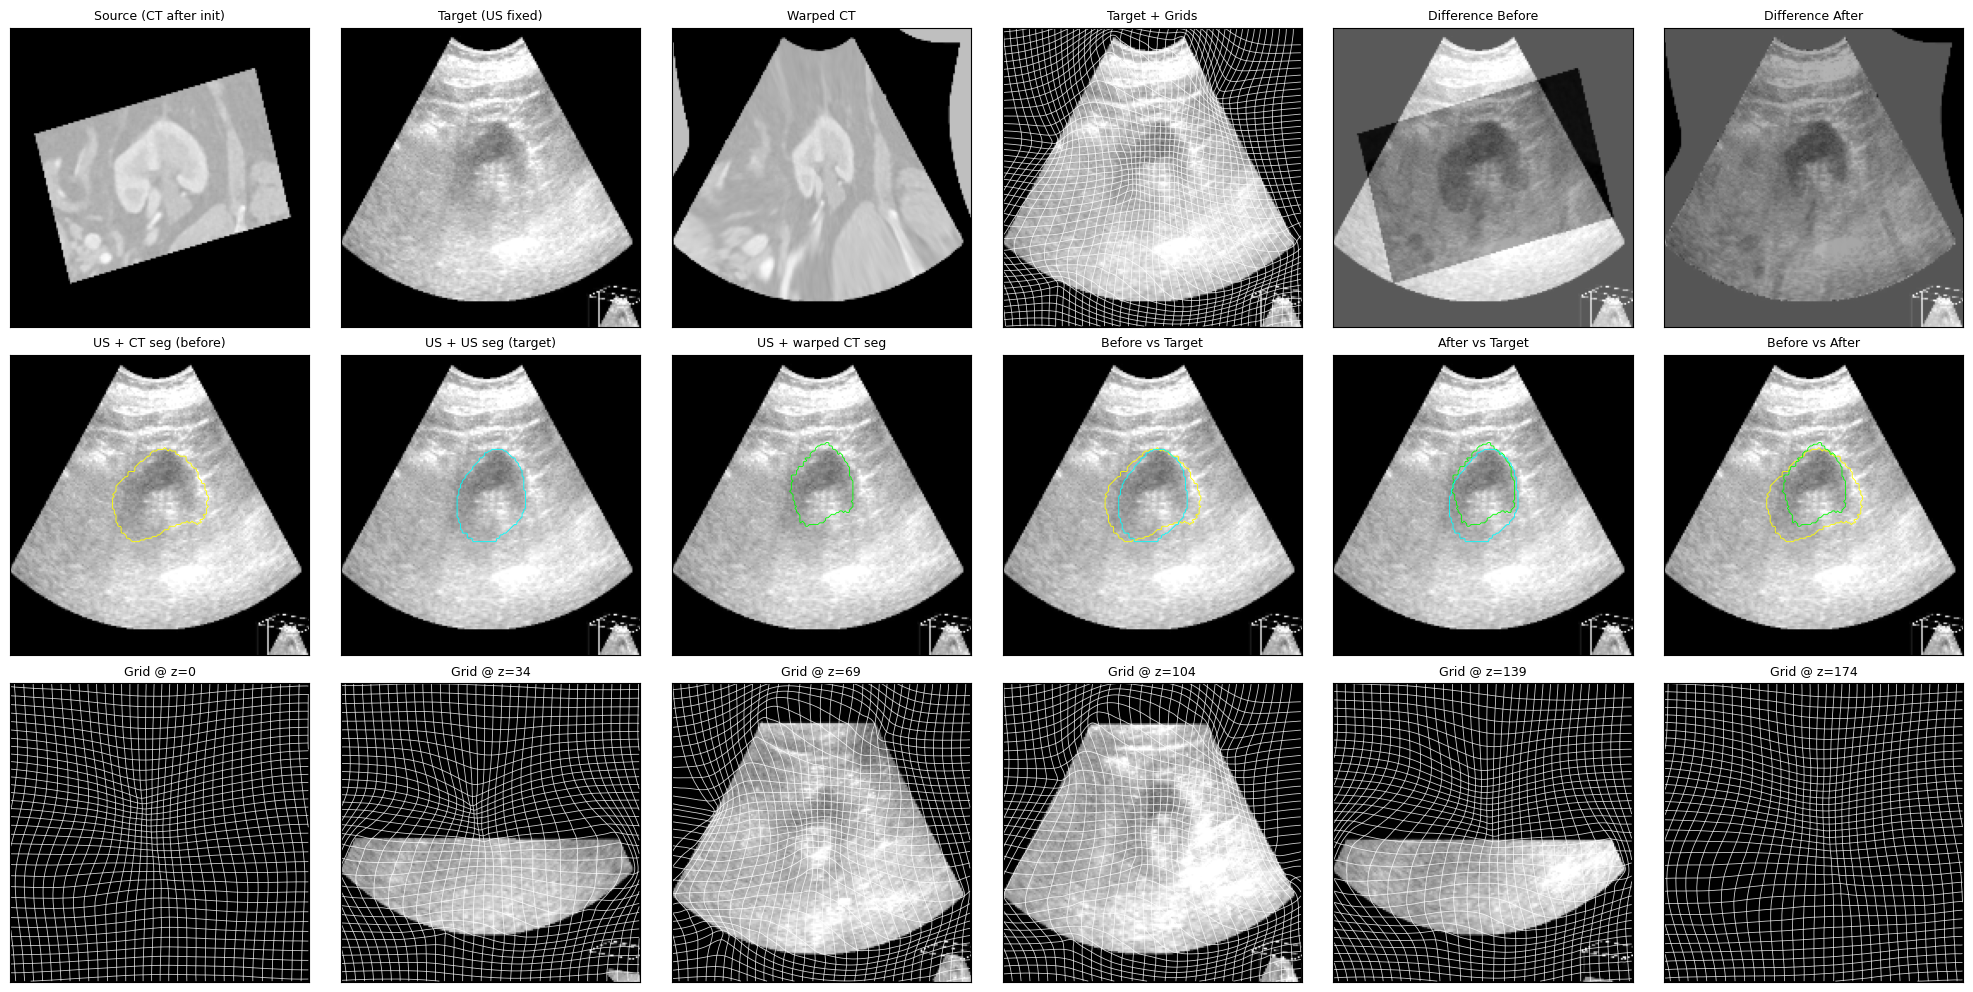

Dice improvement: 0.6947 -> 0.7707


In [8]:
def show_as_grid_contour(ax, phi_slice, linewidth=0.6, stride=6, flip=False):
    data_size = phi_slice.size()[1:]
    plot_phi = phi_slice - 0.5
    n = plot_phi.size()[-1]
    levels = np.linspace(0, n, max(2, int(n / stride)))
    ax.contour(plot_phi[1], levels, linewidths=linewidth, alpha=0.8, colors="w")
    ax.contour(plot_phi[0], levels, linewidths=linewidth, alpha=0.8, colors="w")
    if flip:
        ax.set_ylim([0, data_size[0]])


def show_seg_contours(seg, ax, idx, color):
    seg_slice = seg.cpu()[0, 0, idx].numpy()
    labels = np.unique(seg_slice)
    labels = labels[labels != 0]
    for label in labels:
        ax.contour(seg_slice == label, levels=[0.5], colors=[color], linewidths=0.6)


slice_idx = INPUT_SHAPE[0] // 2
origin = "upper"
font_size = 9

phi_vec = getattr(net, "phi_AB_vectorfield", None)
phi_scaled = None
if phi_vec is not None:
    phi_vec = phi_vec.detach().cpu()
    shape_t = torch.tensor(INPUT_SHAPE, dtype=torch.float32).view(1, 3, 1, 1, 1) - 1
    phi_scaled = phi_vec * shape_t

fig, axes = plt.subplots(3, 6, figsize=(20, 10))

# Row 1: original 6-panel registration view
axes[0, 0].imshow(ct_tensor.cpu()[0, 0, slice_idx], cmap="gray", origin=origin)
axes[0, 1].imshow(us_tensor.cpu()[0, 0, slice_idx], cmap="gray", origin=origin)
axes[0, 2].imshow(warped_ct_tensor.cpu()[0, 0, slice_idx], cmap="gray", origin=origin)
axes[0, 3].imshow(us_tensor.cpu()[0, 0, slice_idx], cmap="gray", origin=origin)
if phi_scaled is not None:
    show_as_grid_contour(axes[0, 3], phi_scaled[0, [1, 2], slice_idx], linewidth=0.6, stride=4)
axes[0, 4].imshow(us_tensor.cpu()[0, 0, slice_idx] - ct_tensor.cpu()[0, 0, slice_idx], cmap="gray", origin=origin)
axes[0, 5].imshow(us_tensor.cpu()[0, 0, slice_idx] - warped_ct_tensor.cpu()[0, 0, slice_idx], cmap="gray", origin=origin)

axes[0, 0].set_title("Source (CT after init)", fontsize=font_size)
axes[0, 1].set_title("Target (US fixed)", fontsize=font_size)
axes[0, 2].set_title("Warped CT", fontsize=font_size)
axes[0, 3].set_title("Target + Grids", fontsize=font_size)
axes[0, 4].set_title("Difference Before", fontsize=font_size)
axes[0, 5].set_title("Difference After", fontsize=font_size)

# Row 2: segmentation overlays and masks
for j in range(6):
    axes[1, j].imshow(us_tensor.cpu()[0, 0, slice_idx], cmap="gray", origin=origin)

show_seg_contours(ct_seg_tensor, axes[1, 0], slice_idx, "yellow")
show_seg_contours(us_seg_tensor, axes[1, 1], slice_idx, "cyan")
show_seg_contours(warped_ct_seg_tensor, axes[1, 2], slice_idx, "lime")
show_seg_contours(ct_seg_tensor, axes[1, 3], slice_idx, "yellow")
show_seg_contours(us_seg_tensor, axes[1, 3], slice_idx, "cyan")
show_seg_contours(warped_ct_seg_tensor, axes[1, 4], slice_idx, "lime")
show_seg_contours(us_seg_tensor, axes[1, 4], slice_idx, "cyan")
show_seg_contours(ct_seg_tensor, axes[1, 5], slice_idx, "yellow")
show_seg_contours(warped_ct_seg_tensor, axes[1, 5], slice_idx, "lime")

axes[1, 0].set_title("US + CT seg (before)", fontsize=font_size)
axes[1, 1].set_title("US + US seg (target)", fontsize=font_size)
axes[1, 2].set_title("US + warped CT seg", fontsize=font_size)
axes[1, 3].set_title("Before vs Target", fontsize=font_size)
axes[1, 4].set_title("After vs Target", fontsize=font_size)
axes[1, 5].set_title("Before vs After", fontsize=font_size)

# Row 3: deformation-grid row across multiple z slices
grid_slices = np.linspace(0, INPUT_SHAPE[0] - 1, 6, dtype=int)
for col, z_idx in enumerate(grid_slices):
    axes[2, col].imshow(us_tensor.cpu()[0, 0, z_idx], cmap="gray", origin=origin)
    if phi_scaled is not None:
        show_as_grid_contour(axes[2, col], phi_scaled[0, [1, 2], z_idx], linewidth=0.6, stride=5)
        axes[2, col].set_title(f"Grid @ z={z_idx}", fontsize=font_size)
    else:
        axes[2, col].text(0.5, 0.5, "No deformation\nfield available", ha="center", va="center")
        axes[2, col].set_title(f"z={z_idx}", fontsize=font_size)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print(f"Dice improvement: {dice_before:.4f} -> {dice_after:.4f}")